# CVE vs CWE

## CVEs Download

In [1]:
!git clone https://github.com/CVEProject/cvelistV5.git

Reverting to default Node version
Now using node v25.8.2 (npm v11.11.1)
fatal: destination path 'cvelistV5' already exists and is not an empty directory.


## Import and install major libraries

In [2]:
!pip install pandas numpy matplotlib

Reverting to default Node version
Now using node v25.8.2 (npm v11.11.1)


In [3]:
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import json
import glob
import re

## Create Data Structures

In [4]:
def parse_cwe_metadata(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    # Define namespaces if necessary, usually CWE XMLs use a specific one
    ns = {'cwe': 'http://cwe.mitre.org/cwe-7'} 
    
    cwe_data = []
    # In CWE XML, weaknesses are usually under a <Weaknesses> tag
    for weakness in root.findall('.//cwe:Weakness', ns):
        cwe_id = weakness.get('ID')
        cwe_data.append({
            'cwe_id': f"CWE-{cwe_id}",
            'name': weakness.get('Name'),
            'abstraction': weakness.get('Abstraction'),
            # You can add logic here to calculate depth/parents later
        })
    return pd.DataFrame(cwe_data)

df_cwe_metadata = parse_cwe_metadata('cwec_v4.19.1.xml')

In [ ]:
def extract_cwes(container):
    found =[]
    descriptions = [d for pt in container.get('problemTypes', []) for d in pt.get('descriptions',[])]
    
    for desc in descriptions:
        if "cweId" in desc:
            found.append(desc["cweId"])
            continue
            
        txt = desc.get('description', '')
        
        # 1. Match numeric IDs: handles spaces, colons, "ID", Unicode dashes (\u2011-\u2014), and URLs
        if match := re.search(r'(?:CWE[\s\-\u2011\u2013\u2014:]*(?:ID\s*)?|definitions/)(\d+)', txt, re.IGNORECASE):
            found.append(f"CWE-{match.group(1)}")
            continue
        # 2. Fallback: If no digits are found but it mentions CWE, Unknown, Other, etc., map to noinfo
        # \b ensures we match whole words (so we don't accidentally match "CWE" inside "macweep")
        elif re.search(r'(?i)\b(?:NOINFO|OTHER|UNKNOWN|CWE|NO_CWE)\b', txt):
            found.append("CWE-noinfo")
            continue
        elif "CWE" in txt.upper():
            print(desc)
            
    return list(set(found))

def parse_all_cves(base_path):
    records =[]
    file_paths = glob.glob(f"{base_path}/**/*.json", recursive=True)
    
    for path in file_paths:
        with open(path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                cve_id = data['cveMetadata']['cveId']

                # Extract from CNA
                cna_cwes = extract_cwes(data['containers'].get('cna', {}))
                
                # Extract from ADP
                adp_cwes =[]
                for adp in data['containers'].get('adp',[]):
                    adp_cwes.extend(extract_cwes(adp))

                # Check for valid CWEs by removing "CWE-noinfo" from the combined set
                valid_cwes = set(cna_cwes + adp_cwes) - {"CWE-noinfo"}

                records.append({
                    'cve_id': cve_id,
                    'year': int(cve_id.split('-')[1]),
                    'published_date': data['cveMetadata'].get('datePublished', None),
                    'cna_cwes': cna_cwes,
                    'adp_cwes': adp_cwes,
                    'has_cwe': len(valid_cwes) > 0  # True only if real CWEs exist
                })
            except Exception:
                continue # Skip malformed files
                
    return pd.DataFrame(records)

df_cve = parse_all_cves('cvelistV5/cves')

df_cve = parse_all_cves('cvelistV5/cves')

In [6]:
len(df_cwe_metadata)

969

In [7]:
len(df_cve)

341110

In [8]:
df_cve_cwe = df_cve.copy()
df_cve_cwe["cwe_id"] = (df_cve_cwe["cna_cwes"] + df_cve_cwe["adp_cwes"]).apply(lambda x: set(x))
df_cve_cwe.drop(["cna_cwes", "adp_cwes"], axis=1, inplace=True)
df_cve_cwe = df_cve_cwe.explode("cwe_id")
df_cve_cwe.fillna("CWE-noinfo", inplace=True);

## General information

### CVE Numbering Authorities vs Authorized Data Publisher

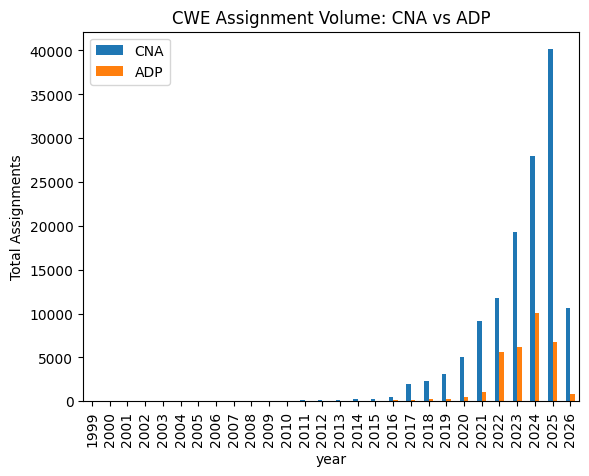

In [9]:
cwe_volume = df_cve.assign(
    CNA=df_cve['cna_cwes'].map(len), 
    ADP=df_cve['adp_cwes'].map(len)
).groupby('year')[['CNA', 'ADP']].sum()

cwe_volume.plot.bar(title='CWE Assignment Volume: CNA vs ADP', ylabel='Total Assignments');

## Metrics calculation

### Coverage

How many CVEs have a CWE associated?

In [56]:
coverage = len(df_cve[df_cve["has_cwe"]==True])/len(df_cve)
print(f"Coverage is {coverage*100:.2f}%")

Coverage is 43.23%


### Cardinality

How many CWEs are associated with a CVE on average?

In [11]:
# Get counts for valid CWEs
valid_counts = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"].groupby("cve_id").size()

# Reindex filling with 0 the CVE without CWEs
all_ids = df_cve_cwe["cve_id"].unique()
overall_counts = valid_counts.reindex(all_ids, fill_value=0)

mean = overall_counts.mean()
std = overall_counts.std()

print(f"Overall Cardinality (All CVEs) is {mean:.2f} ± {std:.2f}")

Overall Cardinality (All CVEs) is 0.47 ± 0.57


In [12]:
valid_counts = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"].groupby("cve_id").size()

mean = valid_counts.mean()
std = valid_counts.std()

print(f"Cardinality (CVEs with >=1 valid CWE) is {mean:.2f} ± {std:.2f}")

Cardinality (CVEs with >=1 valid CWE) is 1.08 ± 0.30


### Popularity

Are there CWEs that occur much more frequently in assignments?

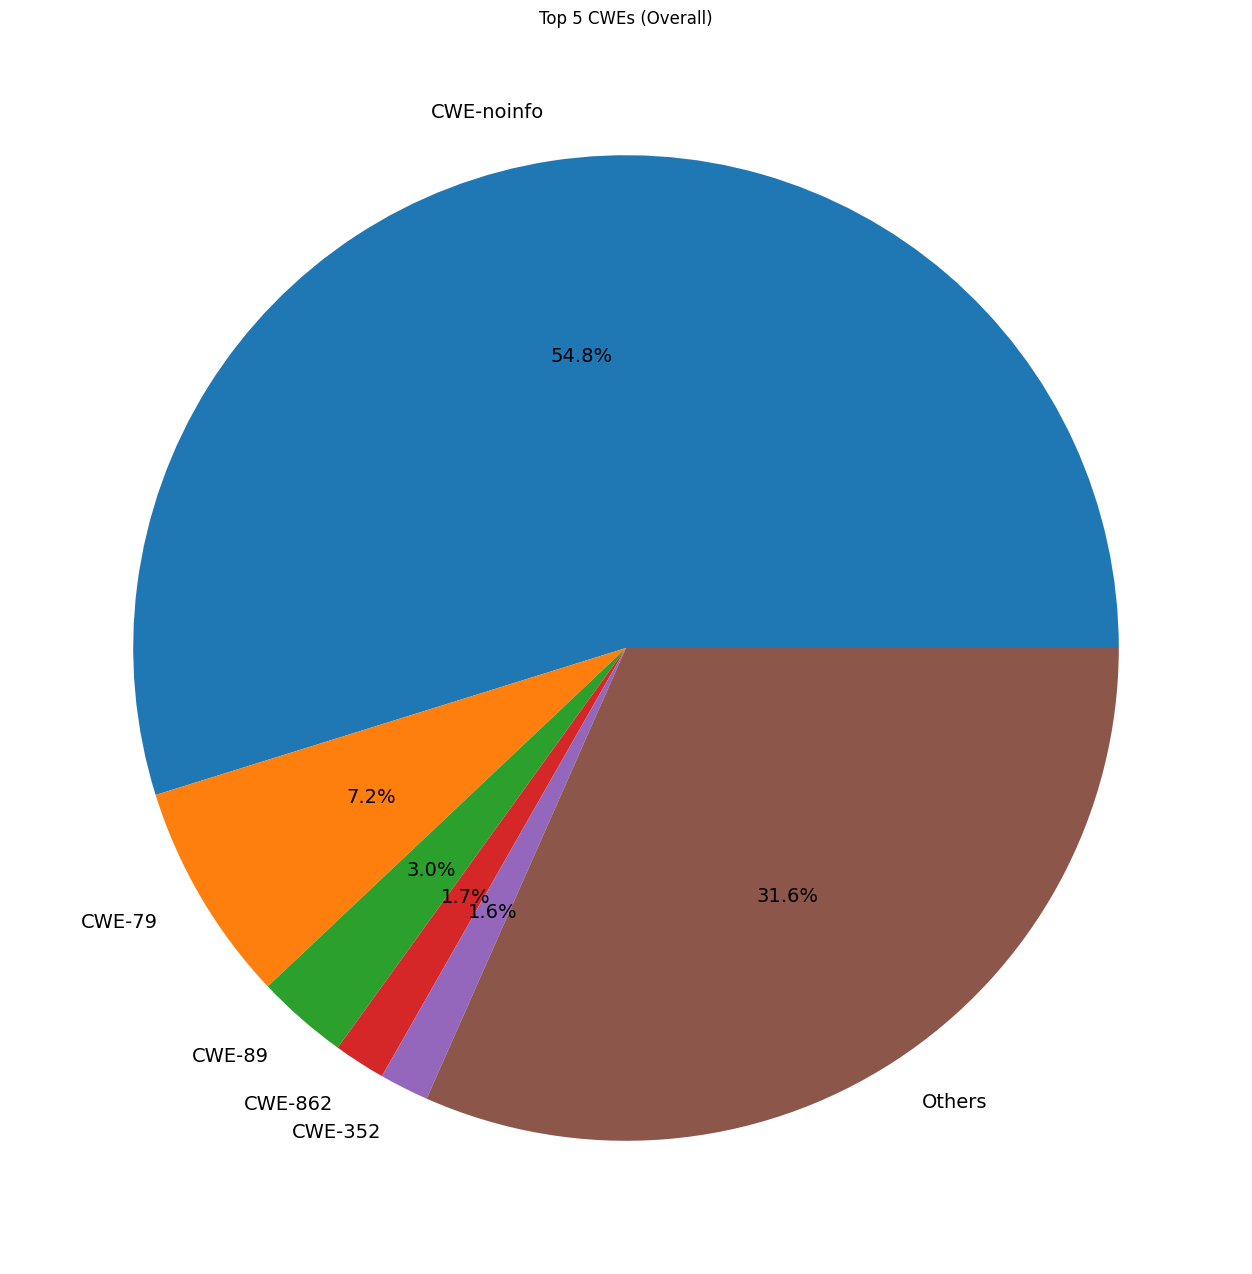

In [58]:
all_counts = df_cve_cwe["cwe_id"].value_counts(normalize=True)
top_5 = all_counts.head(5).copy()
top_5["Others"] = 1.0 - top_5.sum()

plt.figure(figsize=(16, 16))
top_5.plot.pie(autopct='%1.1f%%', ylabel='', title='Top 5 CWEs (Overall)', textprops={'fontsize': 14})# pyright: ignore[reportCallIssue]
plt.show()
# Note that CWE-noinfo is lower then what expected from the coverage, this is because a cve can have more than one cwe

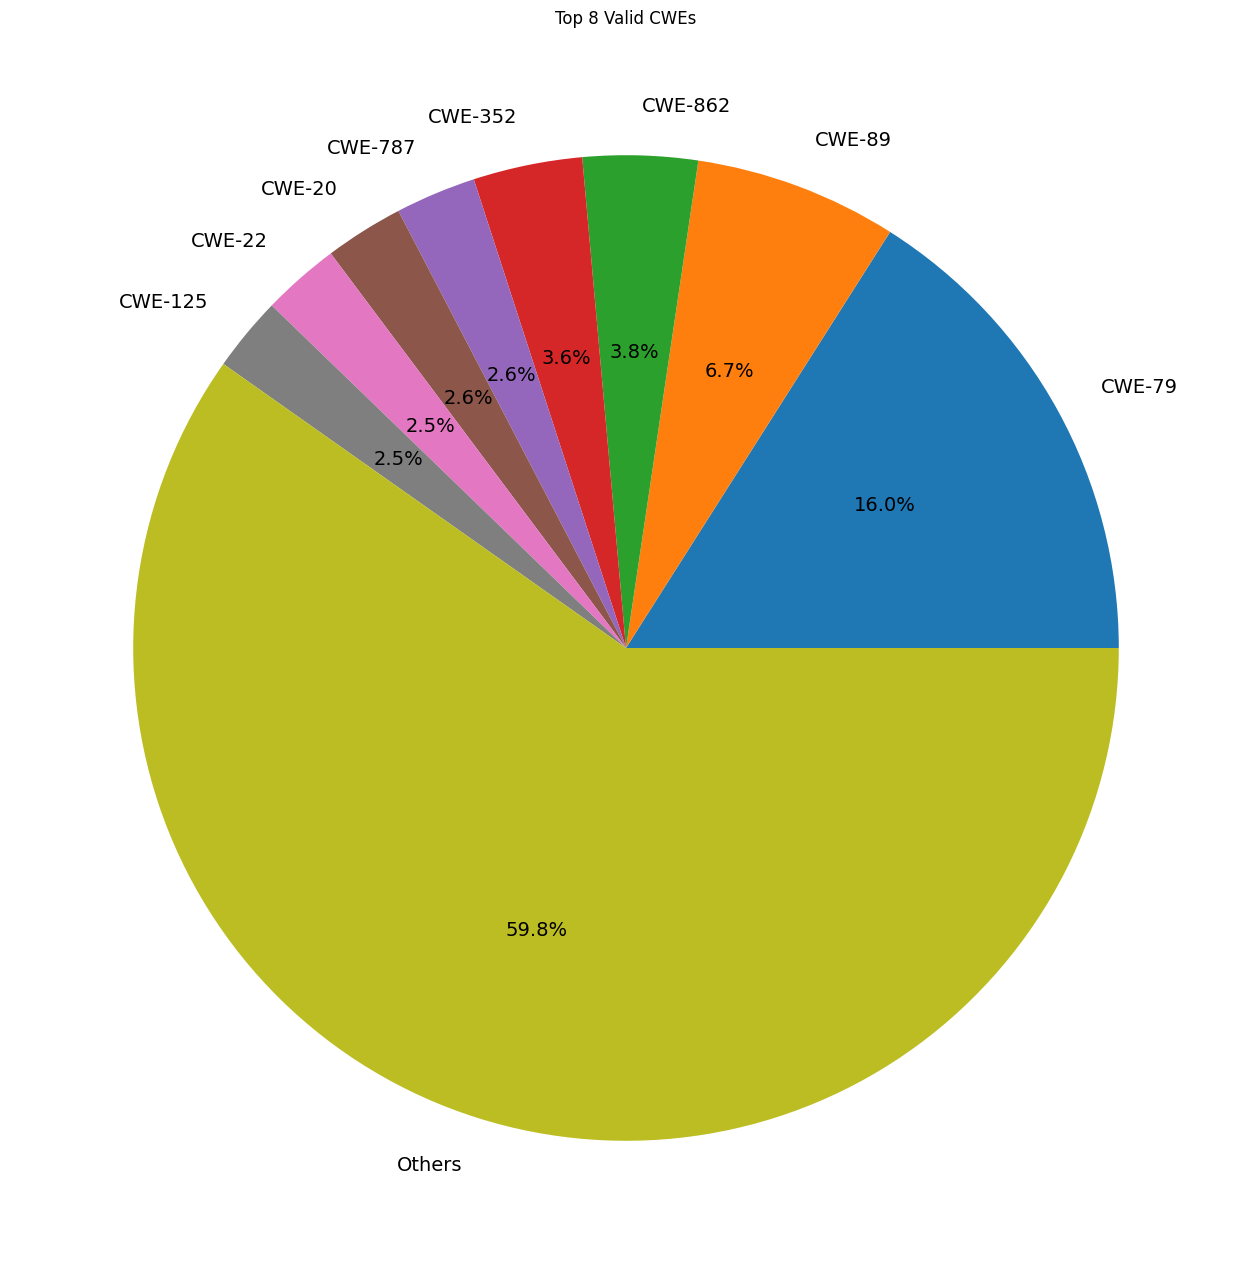

In [59]:
valid_counts = df_cve_cwe[df_cve_cwe["cwe_id"] != "CWE-noinfo"]["cwe_id"].value_counts(normalize=True)
top_8 = valid_counts.head(8).copy()
top_8["Others"] = 1.0 - top_8.sum()

plt.figure(figsize=(16, 16))
top_8.plot.pie(autopct='%1.1f%%', ylabel='', title='Top 8 Valid CWEs', textprops={'fontsize': 14})# pyright: ignore[reportCallIssue]
plt.show()

### Temporal Trends

Is there a trend over time regarding the "density" of assignments (e.g., are modern CVEs being assigned more CWEs than older ones)?

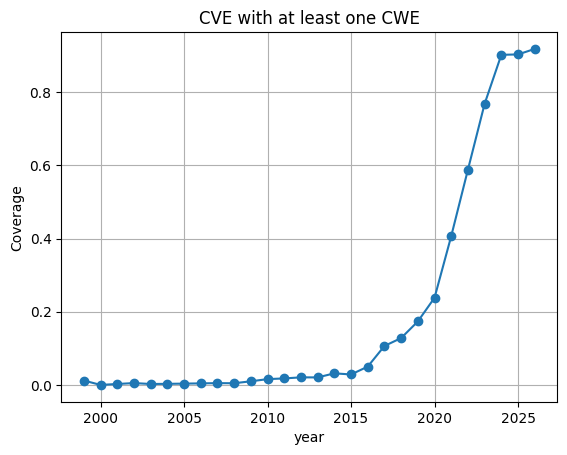

In [15]:
trend = df_cve.groupby('year')['has_cwe'].mean()
cwe_trend = trend.plot(kind='line', marker='o', grid=True, ylabel='Coverage', title='CVE with at least one CWE')

Average assigment 

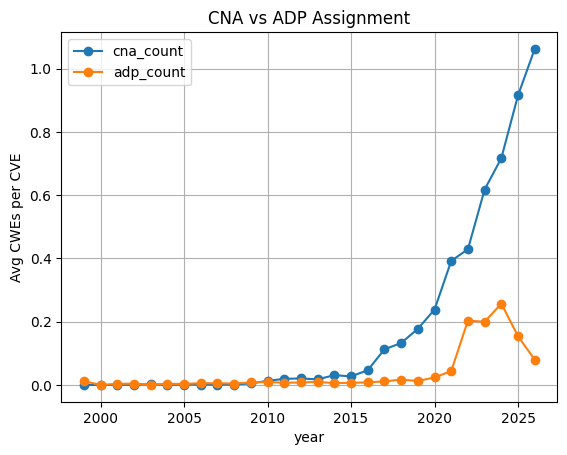

In [16]:
df_cve['cna_count'] = df_cve['cna_cwes'].str.len()
df_cve['adp_count'] = df_cve['adp_cwes'].str.len()

counts_trend = df_cve.groupby('year')[['cna_count', 'adp_count']].mean()
cna_vs_adp_trend = counts_trend.plot(kind='line', marker='o', grid=True, ylabel='Avg CWEs per CVE', title='CNA vs ADP Assignment')

### Completeness

What percentage of CVE records use "placeholder" CWEs (`CWE-noinfo`) vs. actual weakness types?

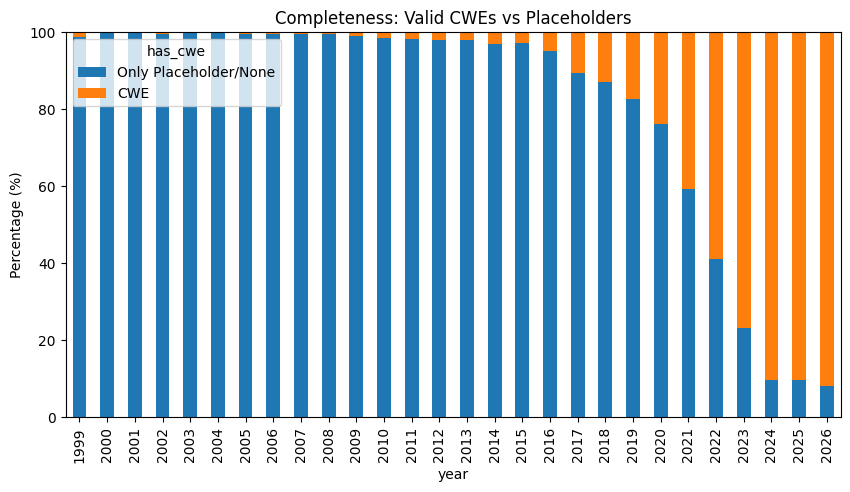

In [17]:
# Get percentages per year
completeness = df_cve.groupby('year')['has_cwe'].value_counts(normalize=True).unstack(fill_value=0).mul(100)

completeness.rename(columns={False: 'Only Placeholder/None', True: 'CWE'}, inplace=True)
completeness_trend = completeness.plot.bar(stacked=True, figsize=(10, 5), title='Completeness: Valid CWEs vs Placeholders', ylabel='Percentage (%)')

### Abstraction Distribution

Are some levels of abstraction (Pillar, Class, Base, Variant) more present in assignments than others?

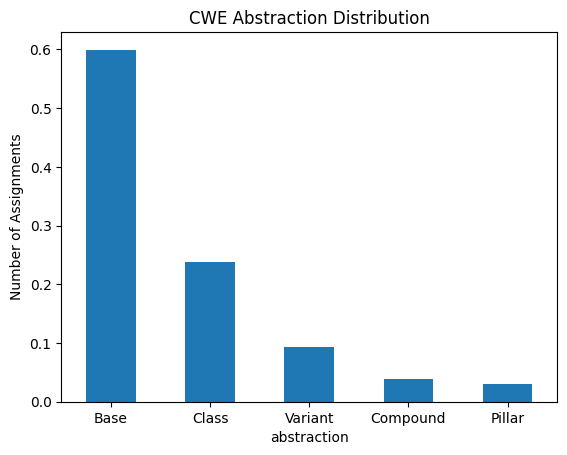

In [18]:
merged_df = df_cve_cwe.merge(df_cwe_metadata, left_on='cwe_id', right_on='cwe_id', how='inner')
abstraction_count = merged_df['abstraction'].value_counts(normalize=True)
abstraction_plot = abstraction_count.plot.bar(title='CWE Abstraction Distribution', ylabel='Number of Assignments', rot=0)

<Axes: title={'center': 'CWE Abstraction Assignments Over Time'}, xlabel='Year', ylabel='Number of Assignments'>

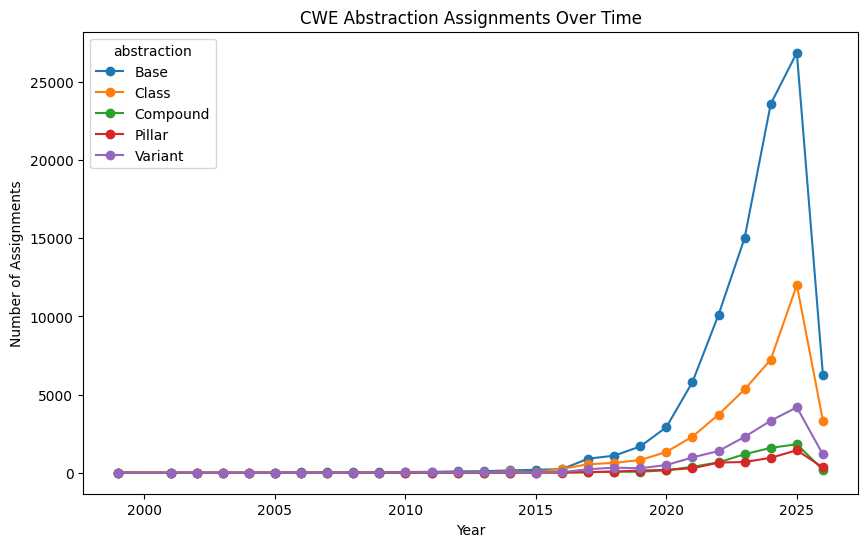

In [19]:
time_counts = merged_df.groupby(['year', 'abstraction']).size()
abstraction_over_time = time_counts.unstack(fill_value=0)

abstraction_over_time.plot.line(
    figsize=(10, 6), 
    marker='o',
    title='CWE Abstraction Assignments Over Time',
    xlabel='Year',
    ylabel='Number of Assignments'
)

From the plot above we can see that many CVE are mapped into "Class" abstractions (could be improved to base), and some are mapped into "Pillar" (Not allowed)

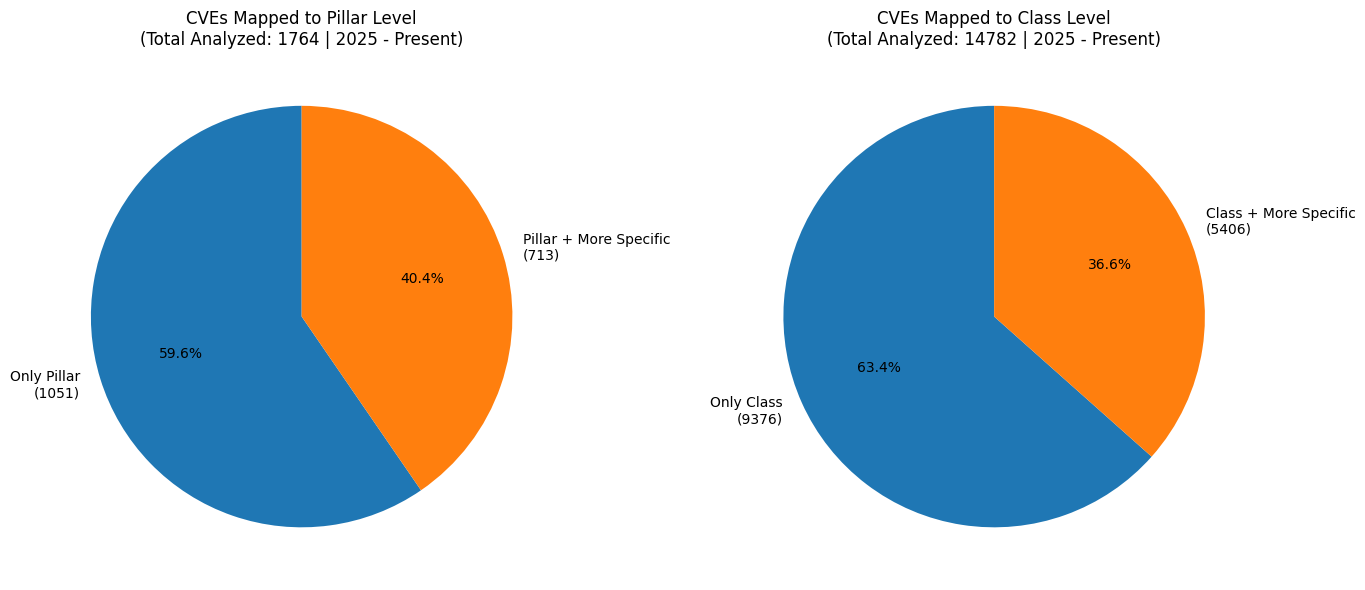

In [20]:
import matplotlib.pyplot as plt

starting_year = 2025
recent_df = merged_df[merged_df['year'].astype(int) >= starting_year]
abs_matrix = pd.crosstab(recent_df['cve_id'], recent_df['abstraction']).astype(bool)

# Define hierarchy of specificity (safely checking if they exist in the dataframe)
cols = abs_matrix.columns.tolist()
pillar_specific =[c for c in ['Class', 'Base', 'Variant', 'Compound'] if c in cols]
class_specific = [c for c in ['Base', 'Variant', 'Compound'] if c in cols]

# Pillar analysis
if 'Pillar' in cols:
    pillar_cves = abs_matrix[abs_matrix['Pillar']]
    # True if the CVE has at least one mapping more specific than Pillar
    pillar_plus_count = pillar_cves[pillar_specific].any(axis=1).sum()
    only_pillar_count = len(pillar_cves) - pillar_plus_count
    total_pillar = len(pillar_cves)
else:
    only_pillar_count, pillar_plus_count, total_pillar = 0, 0, 0

pillar_stats = pd.Series({
    f'Only Pillar\n({only_pillar_count})': only_pillar_count, 
    f'Pillar + More Specific\n({pillar_plus_count})': pillar_plus_count
})

# Class analysis
if 'Class' in cols:
    class_cves = abs_matrix[abs_matrix['Class']]
    # True if the CVE has at least one mapping more specific than Class (ignores Pillar)
    class_plus_count = class_cves[class_specific].any(axis=1).sum()
    only_class_count = len(class_cves) - class_plus_count
    total_class = len(class_cves)
else:
    only_class_count, class_plus_count, total_class = 0, 0, 0

class_stats = pd.Series({
    f'Only Class\n({only_class_count})': only_class_count, 
    f'Class + More Specific\n({class_plus_count})': class_plus_count
})

# Plot the Pie Charts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pillar_stats.plot.pie(
    ax=axes[0], autopct='%1.1f%%', startangle=90, ylabel='', 
    title=f'CVEs Mapped to Pillar Level\n(Total Analyzed: {total_pillar} | {starting_year} - Present)'
) # pyright: ignore[reportCallIssue]

class_stats.plot.pie(
    ax=axes[1], autopct='%1.1f%%', startangle=90, ylabel='', 
    title=f'CVEs Mapped to Class Level\n(Total Analyzed: {total_class} | {starting_year} - Present)'
) # pyright: ignore[reportCallIssue]

plt.tight_layout()

How many CWE contribute to each abstraction type? Is there a "super-cwe" or there are many?

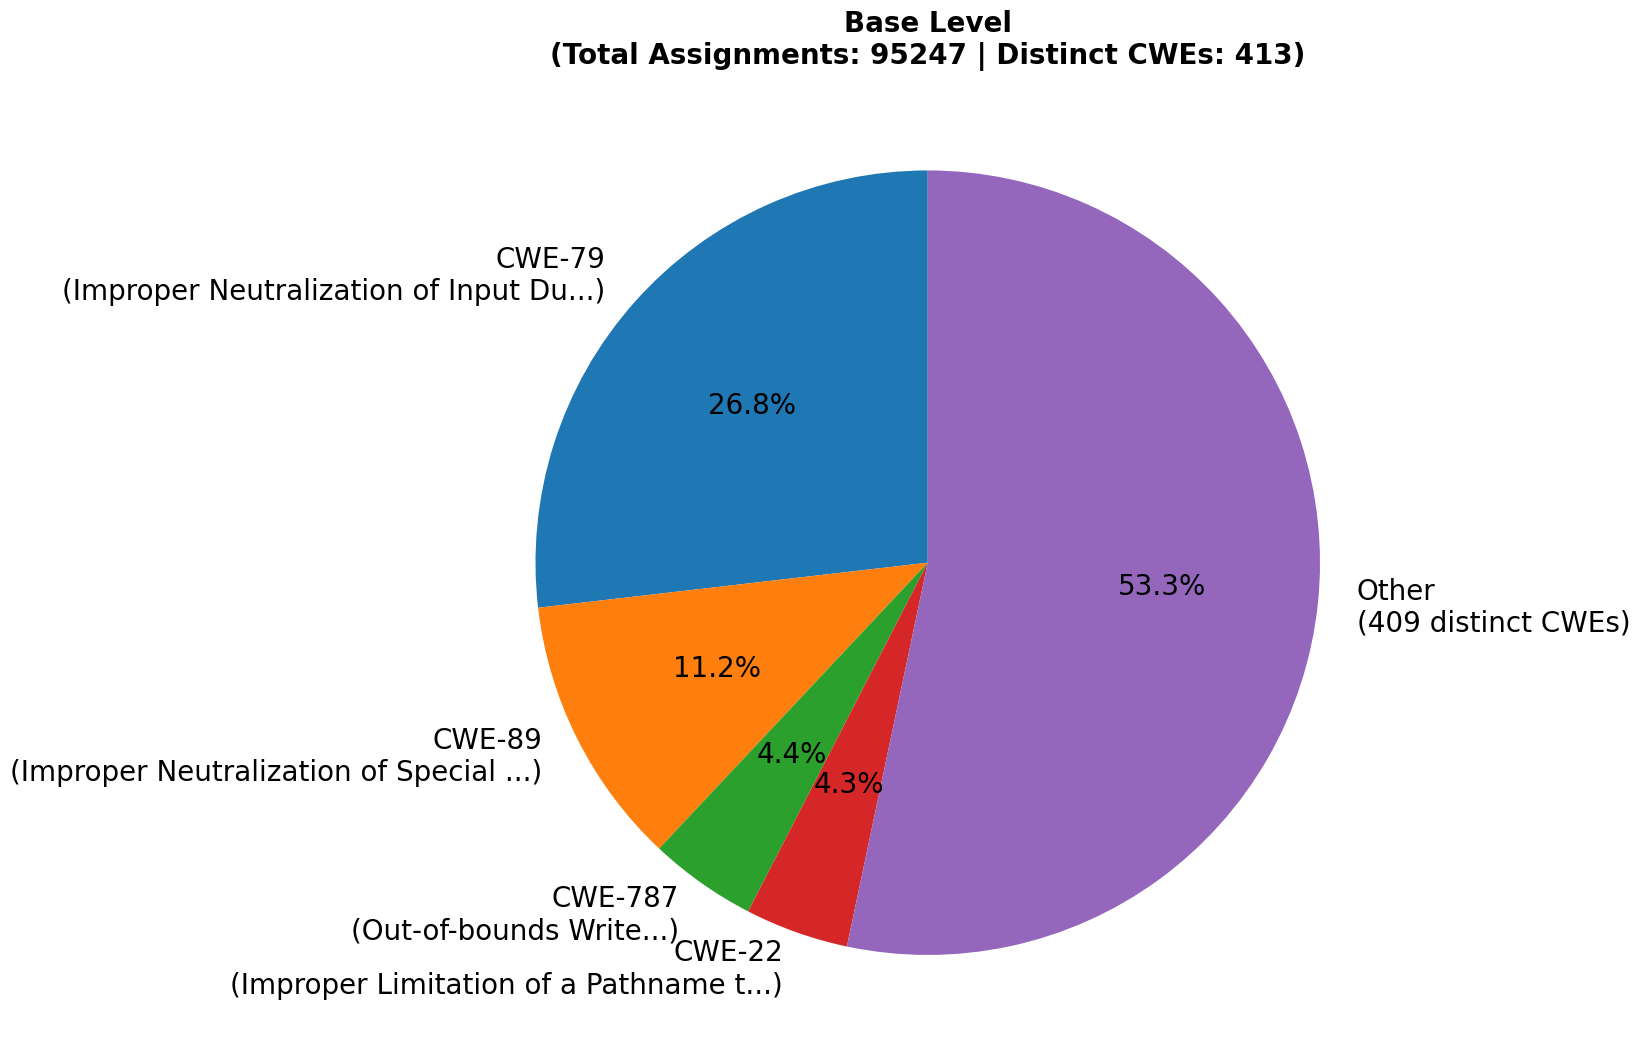

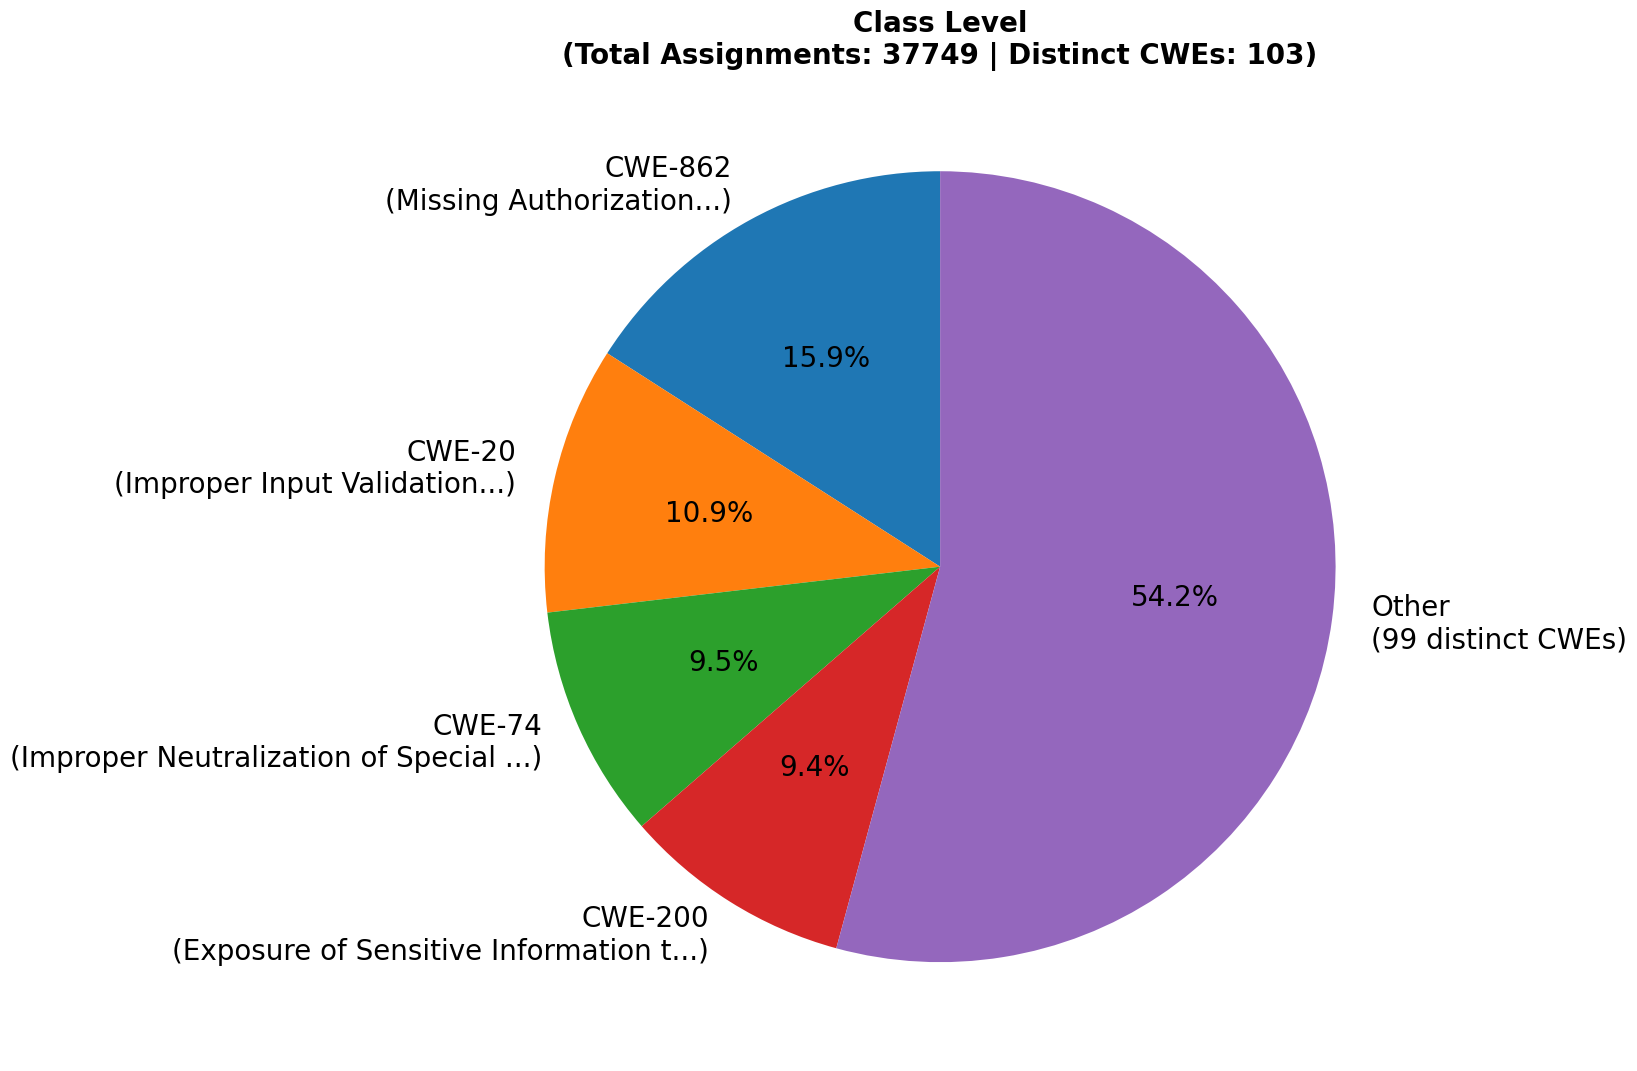

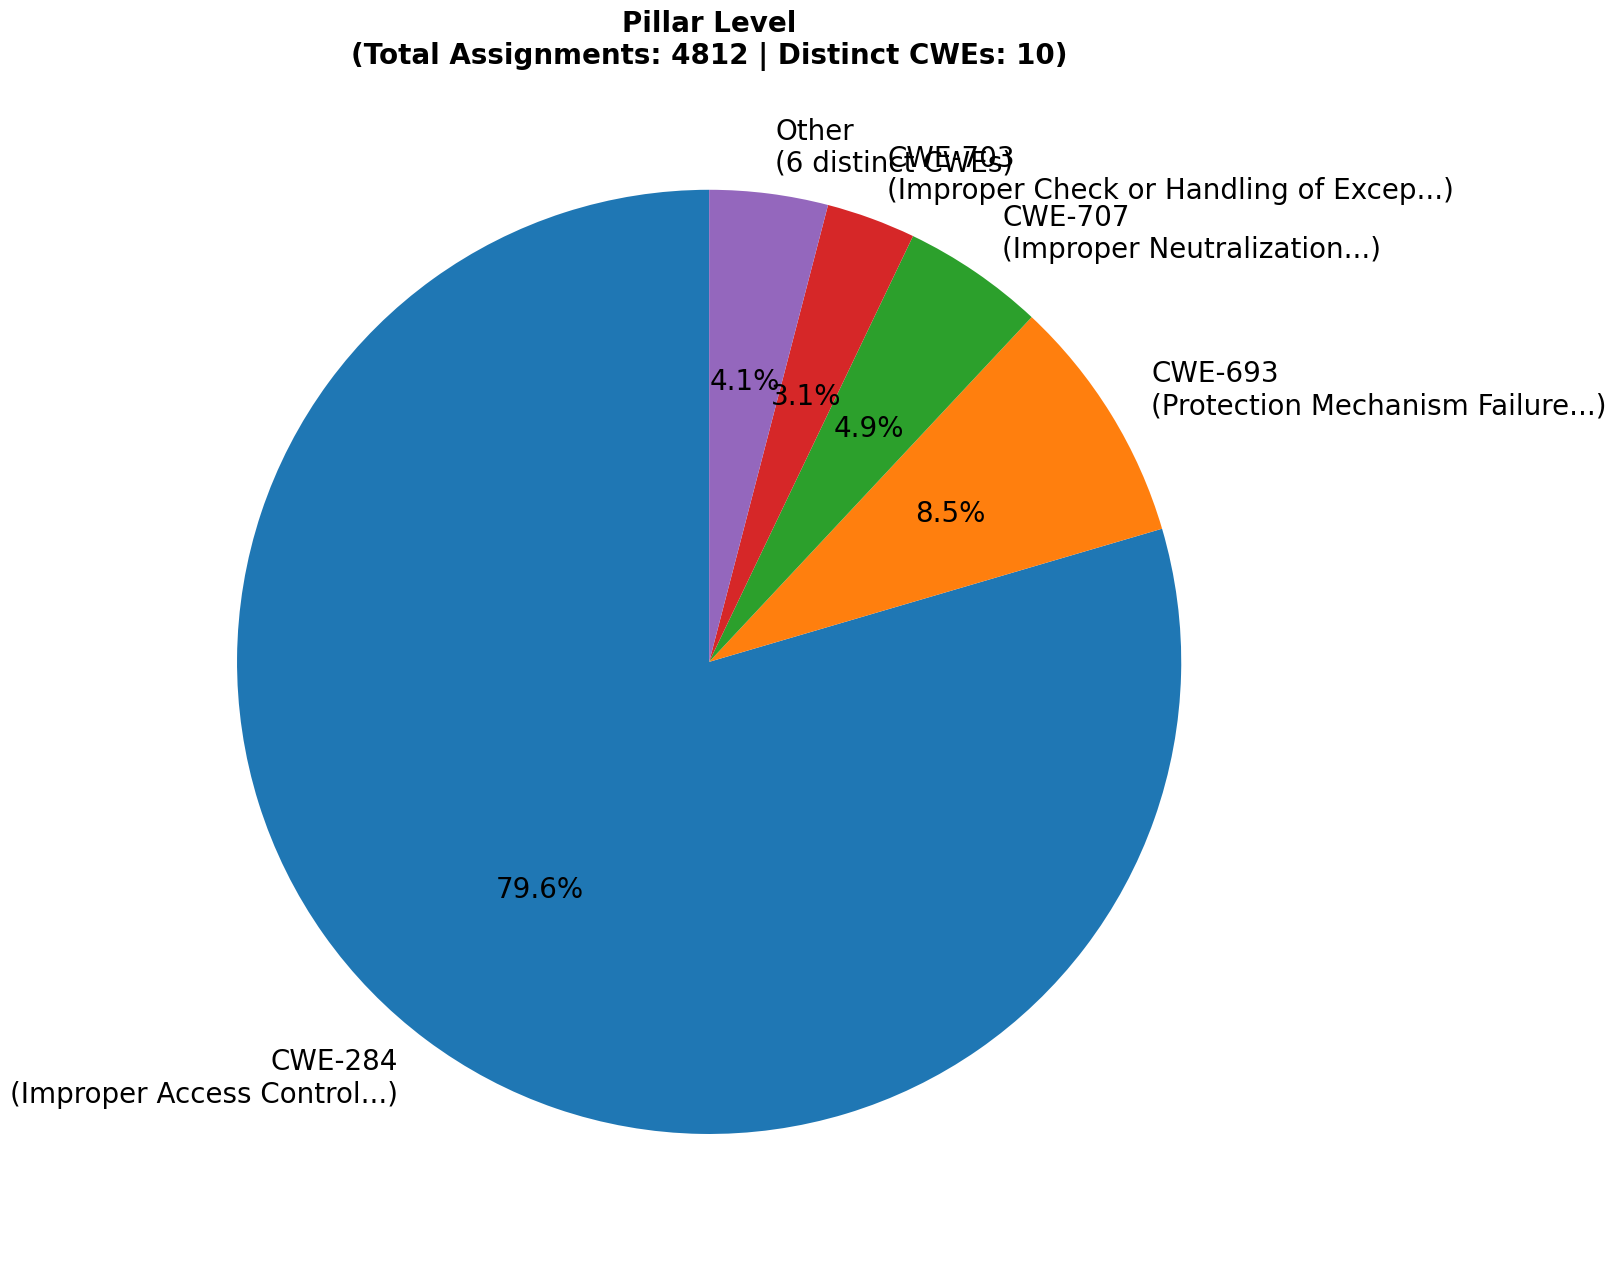

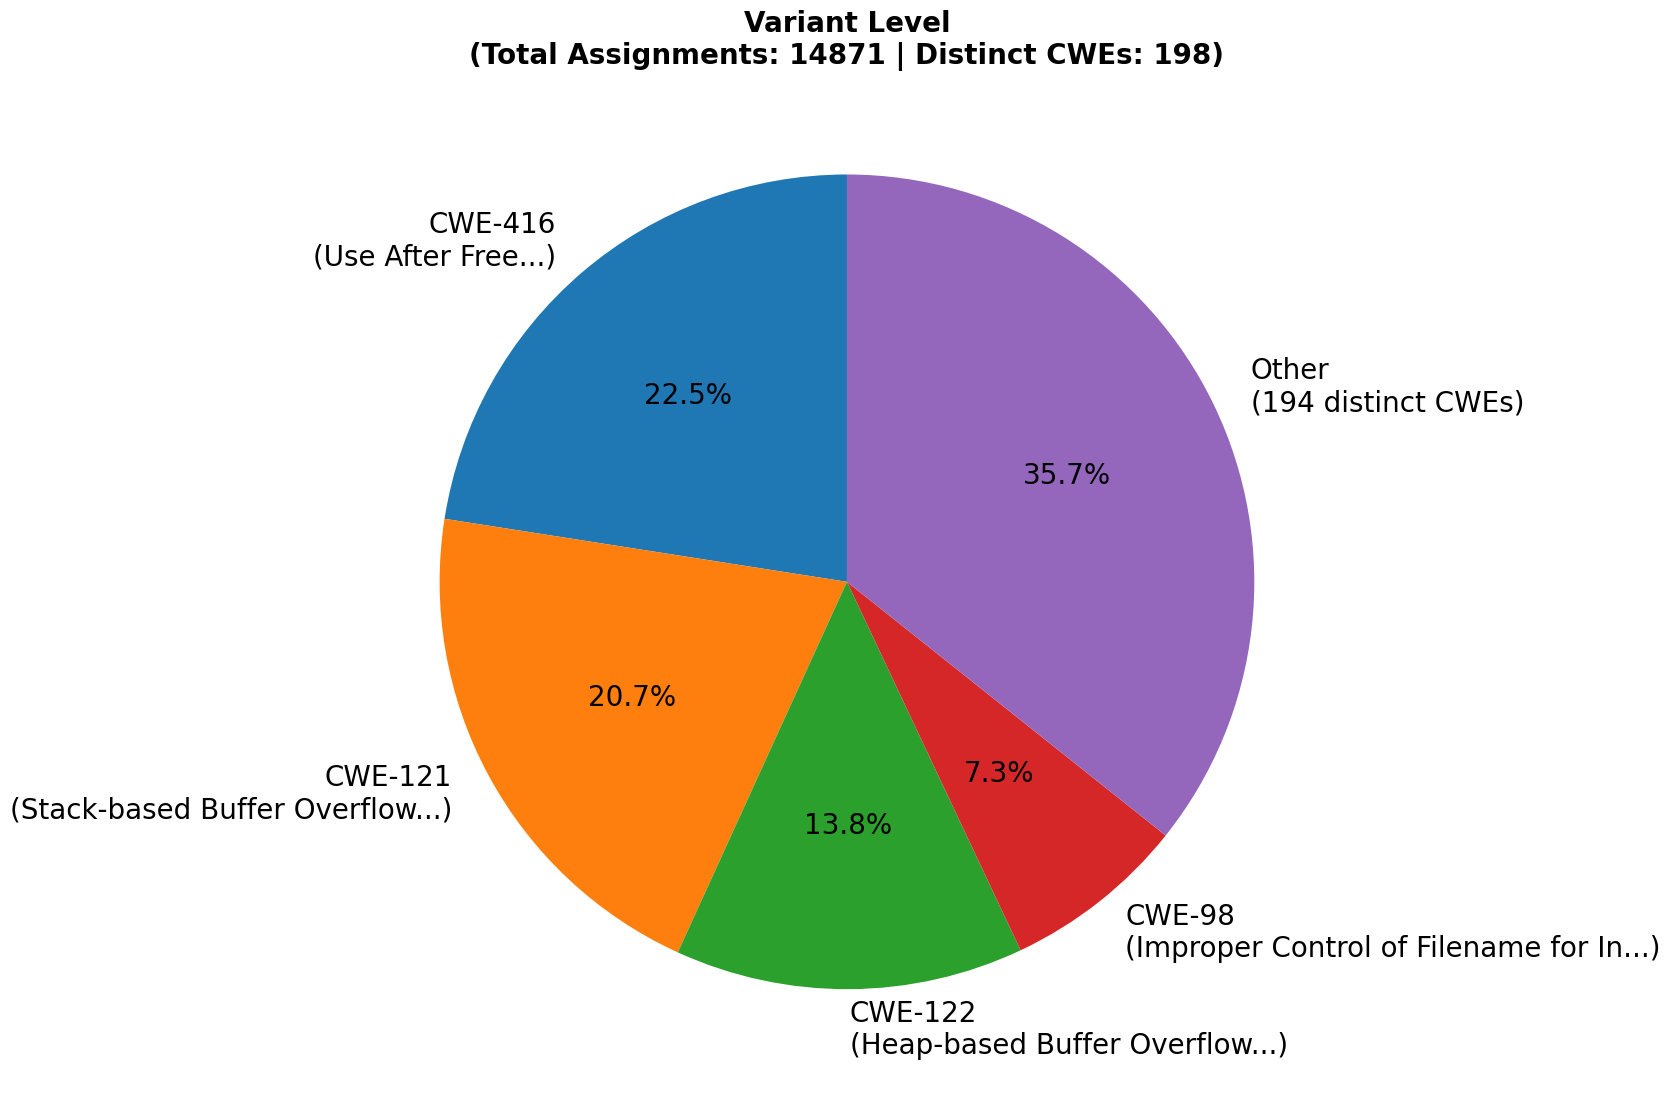

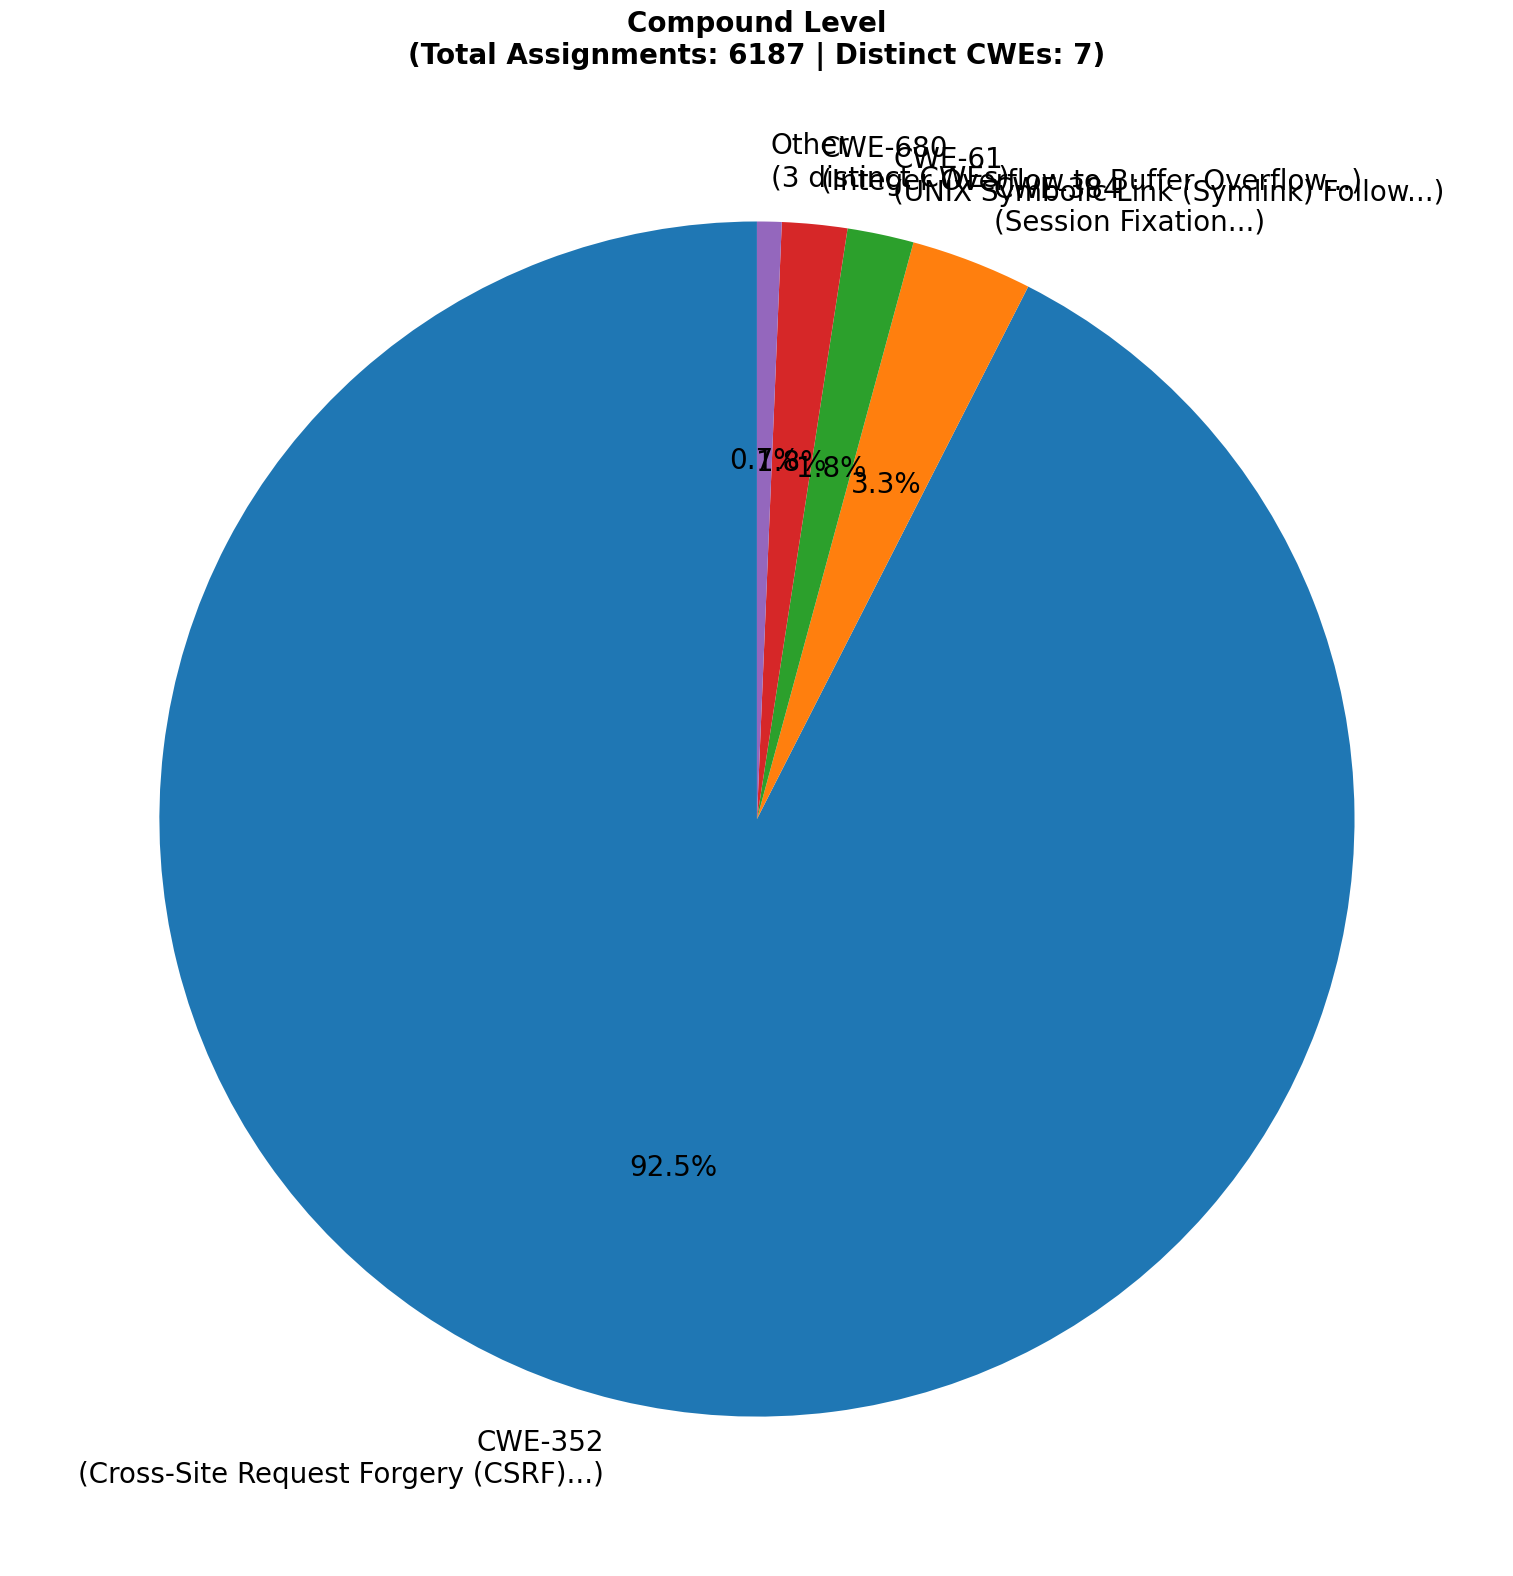

In [68]:
abstractions = merged_df['abstraction'].dropna().unique()
cwe_names = df_cwe_metadata.set_index('cwe_id')['name']

for abs_level in abstractions:
    counts = merged_df[merged_df['abstraction'] == abs_level]['cwe_id'].value_counts()
    
    top4 = counts.head(4)
    others_count = counts.iloc[4:].sum()
    
    plot_data = top4.tolist()
    plot_labels =[f"{cwe}\n({str(cwe_names.get(cwe, 'Unknown'))[:35]}...)" for cwe in top4.index]
    
    if others_count > 0:
        plot_data.append(others_count)
        plot_labels.append(f"Other\n({len(counts) - len(top4)} distinct CWEs)")
        
    plt.figure(figsize=(16, 16))
    plt.pie(plot_data, labels=plot_labels, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 20})
    plt.title(f"{abs_level} Level\n(Total Assignments: {counts.sum()} | Distinct CWEs: {len(counts)})", fontweight='bold', fontsize="20")
    plt.tight_layout()
    plt.show()

### CWE-1003 - View

In [22]:
import xml.etree.ElementTree as ET

tree = ET.parse('cwec_v4.19.1.xml')
root = tree.getroot()
ns = {'cwe': 'http://cwe.mitre.org/cwe-7'}

cwe_1003_members = set()

# 1. Top nodes (Categories/Weaknesses directly attached to the View definition)
for member in root.findall(".//cwe:View[@ID='1003']//cwe:Has_Member", ns):
    cwe_1003_members.add(f"CWE-{member.get('CWE_ID')}")

# 2. Child nodes (Weaknesses explicitly declaring a relationship within View 1003)
for w in root.findall(".//cwe:Weakness", ns):
    if w.find(".//cwe:Related_Weakness[@View_ID='1003']", ns) is not None:
        cwe_1003_members.add(f"CWE-{w.get('ID')}")

print(f"CWE-1003 contains {len(cwe_1003_members)} weaknesses.")

CWE-1003 contains 130 weaknesses.


#### Trend Overtime - All the CVE

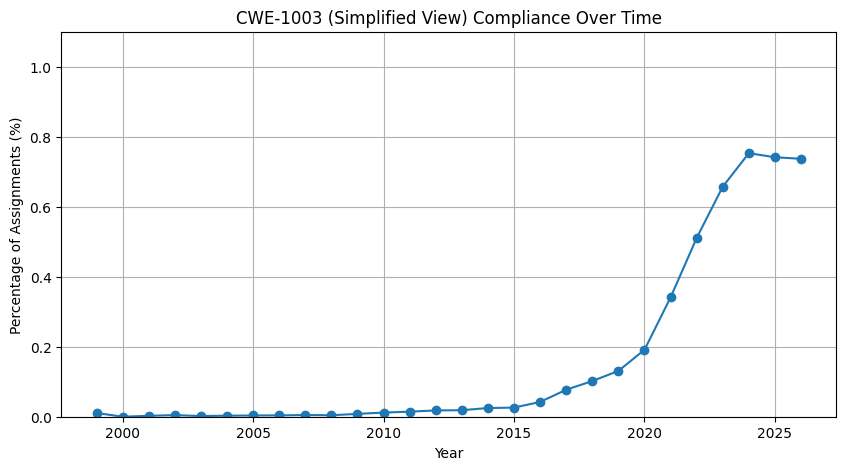

In [23]:
valid_assignments = df_cve_cwe.copy()
valid_assignments['is_1003'] = valid_assignments['cwe_id'].isin(cwe_1003_members)
view_trend = valid_assignments.groupby('year')['is_1003'].mean()

ax = view_trend.plot(
    kind='line', 
    marker='o', 
    grid=True, 
    figsize=(10, 5),
    title='CWE-1003 (Simplified View) Compliance Over Time',
    ylabel='Percentage of Assignments (%)',
    xlabel='Year'
)
ax.set_ylim(0, 1.1);

#### Trend Overtime - Only CVE with associated CWE 

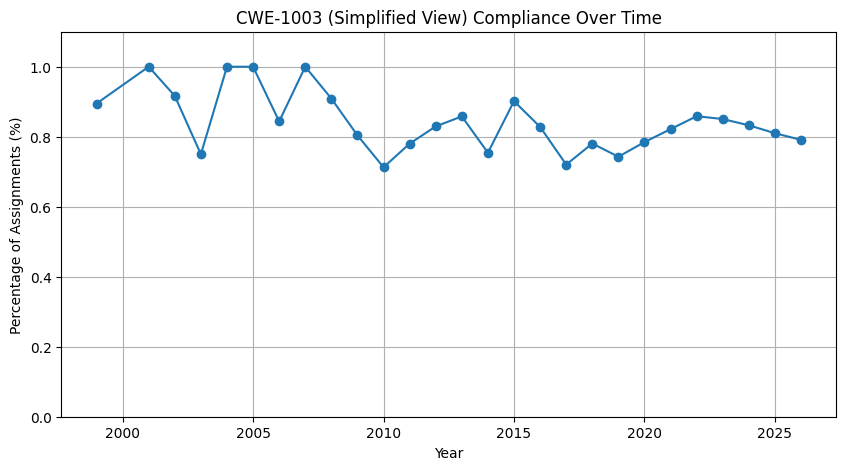

In [24]:
valid_assignments = df_cve_cwe[df_cve_cwe['cwe_id'] != "CWE-noinfo"].copy()
valid_assignments['is_1003'] = valid_assignments['cwe_id'].isin(cwe_1003_members)
view_trend = valid_assignments.groupby('year')['is_1003'].mean()

ax = view_trend.plot(
    kind='line', 
    marker='o', 
    grid=True, 
    figsize=(10, 5),
    title='CWE-1003 (Simplified View) Compliance Over Time',
    ylabel='Percentage of Assignments (%)',
    xlabel='Year'
)
ax.set_ylim(0, 1.1);

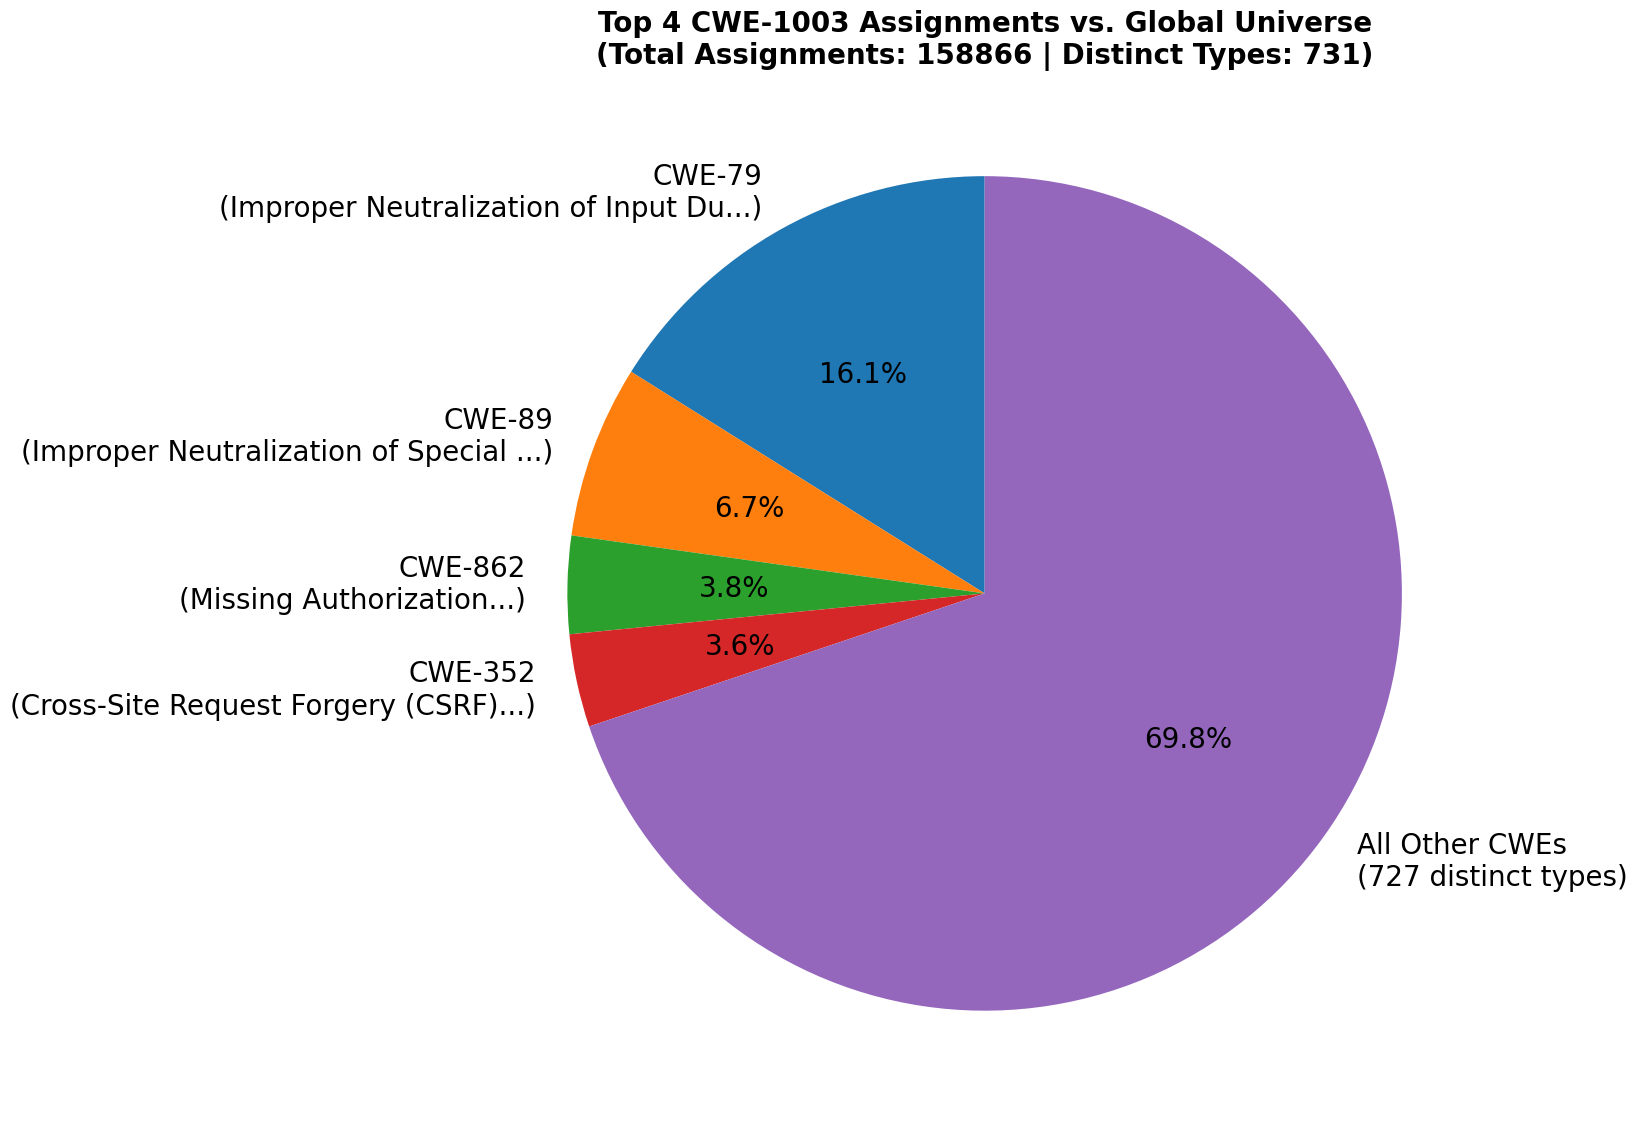

In [70]:
import matplotlib.pyplot as plt

# 1. Calculate global counts and set up metadata lookup
cwe_names = df_cwe_metadata.set_index('cwe_id')['name']
counts = merged_df['cwe_id'].value_counts()

# 2. Identify the Top 4 CWEs that belong to the CWE-1003 view
top4_1003 = counts[counts.index.isin(cwe_1003_members)].head(4)

# 3. Calculate "Others" as the sum of all assignments in the dataset minus the top 4
others_count = counts.sum() - top4_1003.sum()

# 4. Prepare plot data and labels
plot_data = top4_1003.tolist() + [others_count]
plot_labels = [f"{cwe}\n({str(cwe_names.get(cwe, 'Unknown'))[:35]}...)" for cwe in top4_1003.index]
plot_labels.append(f"All Other CWEs\n({len(counts) - 4} distinct types)")

# 5. Plotting
plt.figure(figsize=(16, 16))
plt.pie(
    plot_data, 
    labels=plot_labels, 
    autopct='%1.1f%%', 
    startangle=90, 
    textprops={'fontsize': 20}
)
plt.title(
    f"Top 4 CWE-1003 Assignments vs. Global Universe\n"
    f"(Total Assignments: {counts.sum()} | Distinct Types: {len(counts)})", 
    fontweight='bold', 
    fontsize="20"
)
plt.tight_layout()
plt.show()

### CWE Correlations

Are there CWEs that appear more frequently together in the same CVE record?

In [25]:
valid_df = df_cve_cwe[df_cve_cwe['cwe_id'] != 'CWE-noinfo']
cve_counts = valid_df['cve_id'].value_counts()
multi_cves = cve_counts[cve_counts >= 2].index
df_multi = valid_df[valid_df['cve_id'].isin(multi_cves)]

total_cves = df_cve_cwe['cve_id'].nunique()
pct = (len(multi_cves) / total_cves) * 100
print(f"{len(multi_cves)} CVEs ({pct:.2f}%) have >= 2 valid CWEs.")

11565 CVEs (3.39%) have >= 2 valid CWEs.


#### Jaccard

In [26]:
freq = valid_df['cwe_id'].value_counts()
pairs = df_multi.merge(df_multi, on='cve_id')
pairs = pairs[pairs['cwe_id_x'] < pairs['cwe_id_y']]

jaccard_df = pairs.groupby(['cwe_id_x', 'cwe_id_y']).size().reset_index(name='intersection')
jaccard_df = jaccard_df[jaccard_df['intersection'] >= 5].copy()

union = jaccard_df['cwe_id_x'].map(freq) + jaccard_df['cwe_id_y'].map(freq) - jaccard_df['intersection']
jaccard_df['jaccard'] = jaccard_df['intersection'] / union

top_10_jaccard = jaccard_df.sort_values('jaccard', ascending=False).head(10)
cwe_names = df_cwe_metadata.set_index('cwe_id')['name']

print("=== TOP 10 PAIRS BY JACCARD SIMILARITY ===\n")
for i, r in enumerate(top_10_jaccard.itertuples(), 1):
    name_x = cwe_names.get(r.cwe_id_x, "Unknown")
    name_y = cwe_names.get(r.cwe_id_y, "Unknown")
    print(f"{i}. {r.cwe_id_x} & {r.cwe_id_y} | Jaccard: {r.jaccard:.4f} | Shared CVEs: {r.intersection}")
    print(f"   - {name_x}")
    print(f"   - {name_y}\n")

=== TOP 10 PAIRS BY JACCARD SIMILARITY ===

1. CWE-74 & CWE-89 | Jaccard: 0.2435 | Shared CVEs: 2787
   - Improper Neutralization of Special Elements in Output Used by a Downstream Component ('Injection')
   - Improper Neutralization of Special Elements used in an SQL Command ('SQL Injection')

2. CWE-338 & CWE-340 | Jaccard: 0.1167 | Shared CVEs: 14
   - Use of Cryptographically Weak Pseudo-Random Number Generator (PRNG)
   - Generation of Predictable Numbers or Identifiers

3. CWE-378 & CWE-379 | Jaccard: 0.1163 | Shared CVEs: 10
   - Creation of Temporary File With Insecure Permissions
   - Creation of Temporary File in Directory with Insecure Permissions

4. CWE-119 & CWE-120 | Jaccard: 0.1101 | Shared CVEs: 512
   - Improper Restriction of Operations within the Bounds of a Memory Buffer
   - Buffer Copy without Checking Size of Input ('Classic Buffer Overflow')

5. CWE-266 & CWE-285 | Jaccard: 0.1092 | Shared CVEs: 186
   - Incorrect Privilege Assignment
   - Improper Authorizatio

#### Data Mining

In [27]:
N = valid_df['cve_id'].nunique()
freq = valid_df['cwe_id'].value_counts()

pairs = df_multi.merge(df_multi, on='cve_id')
pairs = pairs[pairs['cwe_id_x'] < pairs['cwe_id_y']]
mining_df = pairs.groupby(['cwe_id_x', 'cwe_id_y']).size().reset_index(name='intersection')
mining_df = mining_df[mining_df['intersection'] >= 5].copy()

freq_x = mining_df['cwe_id_x'].map(freq)
freq_y = mining_df['cwe_id_y'].map(freq)

mining_df['conf_X_to_Y'] = mining_df['intersection'] / freq_x
mining_df['conf_Y_to_X'] = mining_df['intersection'] / freq_y
mining_df['lift'] = mining_df['conf_X_to_Y'] / (freq_y / N)

top_10_mining = mining_df.sort_values('lift', ascending=False).head(10)
cwe_names = df_cwe_metadata.set_index('cwe_id')['name']

print("=== TOP 10 PAIRS BY LIFT (DATA MINING) ===\n")
for i, r in enumerate(top_10_mining.itertuples(), 1):
    name_x = cwe_names.get(r.cwe_id_x, "Unknown")
    name_y = cwe_names.get(r.cwe_id_y, "Unknown")
    print(f"{i}. [X] {r.cwe_id_x} & [Y] {r.cwe_id_y} | Lift: {r.lift:.1f} | Conf X->Y: {r.conf_X_to_Y:.1%} | Conf Y->X: {r.conf_Y_to_X:.1%}")
    print(f"   [X] {name_x}")
    print(f"[Y] {name_y}\n")

=== TOP 10 PAIRS BY LIFT (DATA MINING) ===

1. [X] CWE-363 & [Y] CWE-61 | Lift: 724.7 | Conf X->Y: 54.5% | Conf Y->X: 5.4%
   [X] Race Condition Enabling Link Following
[Y] UNIX Symbolic Link (Symlink) Following

2. [X] CWE-378 & [Y] CWE-379 | Lift: 644.6 | Conf X->Y: 22.7% | Conf Y->X: 19.2%
   [X] Creation of Temporary File With Insecure Permissions
[Y] Creation of Temporary File in Directory with Insecure Permissions

3. [X] CWE-338 & [Y] CWE-340 | Lift: 607.3 | Conf X->Y: 14.0% | Conf Y->X: 41.2%
   [X] Use of Cryptographically Weak Pseudo-Random Number Generator (PRNG)
[Y] Generation of Predictable Numbers or Identifiers

4. [X] CWE-1336 & [Y] CWE-791 | Lift: 402.3 | Conf X->Y: 7.1% | Conf Y->X: 38.5%
   [X] Improper Neutralization of Special Elements Used in a Template Engine
[Y] Incomplete Filtering of Special Elements

5. [X] CWE-320 & [Y] CWE-321 | Lift: 362.1 | Conf X->Y: 62.9% | Conf Y->X: 8.6%
   [X] Unknown
[Y] Use of Hard-coded Cryptographic Key

6. [X] CWE-331 & [Y] CWE-